In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from copy import deepcopy

# Euclid software
from cloelite.cosmology.jax_cosmology import JAXBackground
from cloelite.cosmology.jax_cosmology import JAXLinearPerturbations
from cloelite.cosmology.jax_cosmology import JAXNonLinearPerturbations
from cloelite.observables import photo
import euclidlib as el

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=20)

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.0' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:62: UserWarning: Pandas requires version '1.3.4' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
# Read the dndz
z_pos, dndz_pos = el.photo.redshift_distributions('data/nz.pos.fits')
z_she, dndz_she = el.photo.redshift_distributions('data/nz.wl.fits')

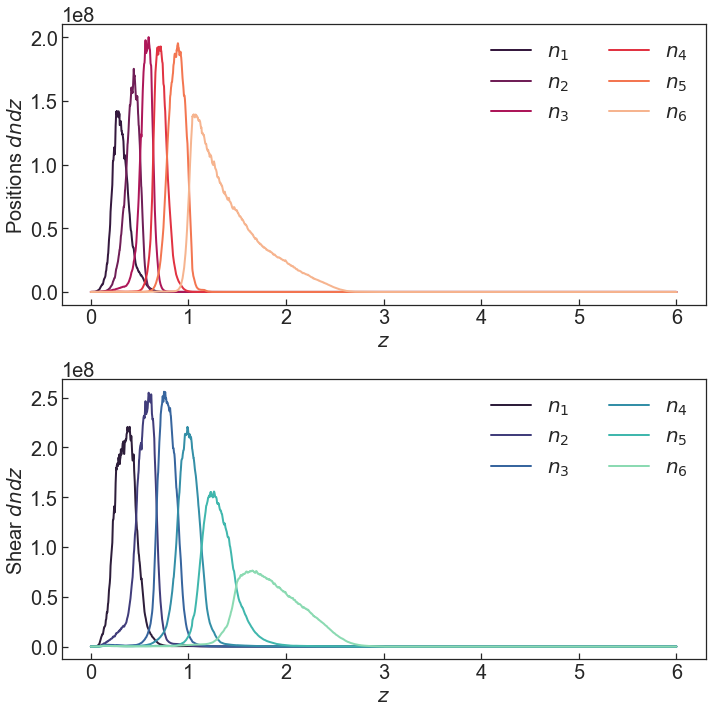

In [3]:
# Plot the dndz
i = 0
j = 0
fig, axs = plt.subplots(2, 1, figsize=(10,10))
for ax in axs.flatten():
    ax.tick_params(axis='both',which='both',direction='in')
for key in dndz_pos.keys():
    axs[0].plot(z_pos, dndz_pos[key], label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=sns.color_palette("rocket", len(dndz_pos.keys()))[i])
    i=i+1
for key in dndz_she.keys():
    axs[1].plot(z_she, dndz_she[key], label = '$n_{{{}}}$'.format(j+1), linewidth=2, color=sns.color_palette("mako", len(dndz_pos.keys()))[j])
    j=j+1
axs[0].set_xlabel(r'$z$')
axs[0].set_ylabel(r'Positions $dndz$ ')
axs[0].legend(frameon=False, ncol=2)
axs[1].set_xlabel(r'$z$')
axs[1].set_ylabel(r'Shear $dndz$ ')
axs[1].legend(frameon=False, ncol=2);
plt.tight_layout()


In [4]:
# Normalise dndz
dndz_pos_norm = deepcopy(dndz_pos)
for key in dndz_pos.keys():
    dndz_pos_norm[key] = dndz_pos[key] / integrate.trapezoid(
                        dndz_pos[key], z_pos)
    
dndz_she_norm = deepcopy(dndz_she)
for key in dndz_she.keys():
    dndz_she_norm[key] = dndz_she[key] / integrate.trapezoid(
                        dndz_she[key], z_she)

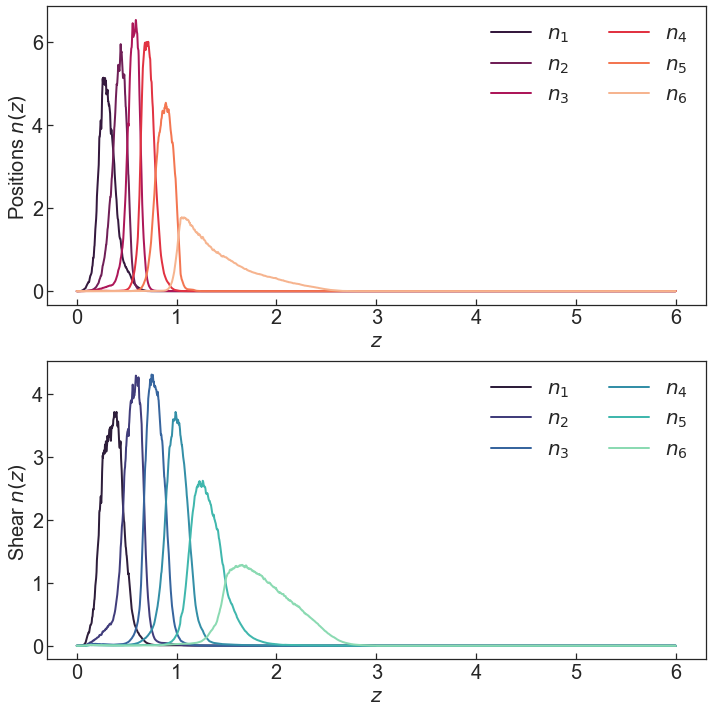

In [5]:
# Plot the dndz
i = 0
j = 0
fig, axs = plt.subplots(2, 1, figsize=(10,10))
for ax in axs.flatten():
    ax.tick_params(axis='both',which='both',direction='in')
for key in dndz_pos.keys():
    axs[0].plot(z_pos, dndz_pos_norm[key], label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=sns.color_palette("rocket", len(dndz_pos.keys()))[i])
    i=i+1
for key in dndz_she.keys():
    axs[1].plot(z_she, dndz_she_norm[key], label = '$n_{{{}}}$'.format(j+1), linewidth=2, color=sns.color_palette("mako", len(dndz_pos.keys()))[j])
    j=j+1
axs[0].set_xlabel(r'$z$')
axs[0].set_ylabel(r'Positions $n(z)$ ')
axs[0].legend(frameon=False, ncol=2)
axs[1].set_xlabel(r'$z$')
axs[1].set_ylabel(r'Shear $n(z)$ ')
axs[1].legend(frameon=False, ncol=2);
plt.tight_layout()

In [6]:
# Initialize Background cosmology
# Cosmology parameters
H0 =  67.7
h = H0/100.
sigma8 = 0.8277
Omm = 0.3097
Omc = 0.26067408193677466
Omb = 0.04902591806322532
w = -1
wa = 0

background = JAXBackground(H0=H0,Omc=Omc,Omb=Omb, w=w, wa=wa, sigma8=sigma8, Omk = 0.0, ns = 0.96, gamma_MG = 0.545)

In [7]:
# Initialize Linear and NonLinearPerturbations
linear_pert = JAXLinearPerturbations(background)
nonlinear_pert = JAXNonLinearPerturbations(linear_pert)

In [9]:

tracer_she = photo.ShearTracer(nonlinear_pert, 
                            dndz=dndz_she_norm, 
                            z = z_she,
                            intrinsic_aligment_model='zNLA',
                            nuisance_params={'param1': 1.0})

tracer_pos = photo.PositionsTracer(nonlinear_pert, 
                            dndz=dndz_she_norm, 
                            z = z_pos,                            
                            magnification_bias_model = 'linear',
                            galaxy_bias_model= 'linear',
                            nuisance_params={'param1': 1.0})

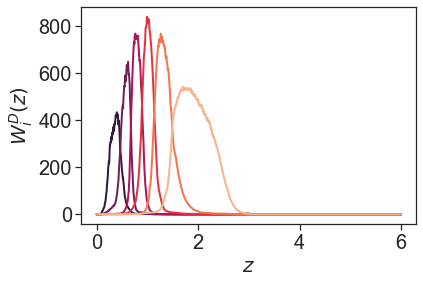

In [10]:
# Careful about the units of H(z)
# Note the D for positions (euclidlib internal map pointer :) )
for i in dndz_pos.keys():
    plt.plot(z_pos, tracer_pos.get_window_positions(z_pos)[i-1], linewidth=2, color=sns.color_palette("rocket", len(dndz_pos.keys()))[i-1])
plt.xlabel(r'$z$')
plt.ylabel(r'$W^D_i(z)$');